In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
df = pd.read_csv('customer_segmentation_data.csv')
df.head()

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36
3,4,40,Other,47099,74,9,5,Home & Garden,991.93
4,5,65,Female,140621,21,3,25,Electronics,347.08


In [5]:
df.drop('id',axis=1,inplace=True)

In [6]:
df.head()

,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,38,Female,99342,90,3,24,Groceries,113.53
1,21,Female,78852,60,2,42,Sports,41.93
2,60,Female,126573,30,2,28,Clothing,424.36
3,40,Other,47099,74,9,5,Home & Garden,991.93
4,65,Female,140621,21,3,25,Electronics,347.08


In [7]:
df.isna().sum(0)

C:\Users\HP\AppData\Local\Temp\ipykernel_17916\3037201259.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  df.isna().sum(0)


age                     0
gender                  0
income                  0
spending_score          0
membership_years        0
purchase_frequency      0
preferred_category      0
last_purchase_amount    0
dtype: int64

In [8]:
df.shape

(1000, 8)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   1000 non-null   int64  
 1   gender                1000 non-null   str    
 2   income                1000 non-null   int64  
 3   spending_score        1000 non-null   int64  
 4   membership_years      1000 non-null   int64  
 5   purchase_frequency    1000 non-null   int64  
 6   preferred_category    1000 non-null   str    
 7   last_purchase_amount  1000 non-null   float64
dtypes: float64(1), int64(5), str(2)
memory usage: 76.7 KB


In [10]:
df['gender'].unique()

<ArrowStringArray>
['Female', 'Other', 'Male']
Length: 3, dtype: str

In [11]:
df['gender']=df['gender'].replace({'Female':1, 'Other':2, 'Male':0})
df['gender']=df['gender'].astype(int)

In [12]:
df['preferred_category'].unique()

<ArrowStringArray>
['Groceries', 'Sports', 'Clothing', 'Home & Garden', 'Electronics']
Length: 5, dtype: str

In [13]:
df['preferred_category']=df['preferred_category'].replace({'Groceries':0, 'Sports':1, 'Clothing':2, 'Home & Garden':3, 'Electronics':4})
df['preferred_category']=df['preferred_category'].astype(int)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   1000 non-null   int64  
 1   gender                1000 non-null   int64  
 2   income                1000 non-null   int64  
 3   spending_score        1000 non-null   int64  
 4   membership_years      1000 non-null   int64  
 5   purchase_frequency    1000 non-null   int64  
 6   preferred_category    1000 non-null   int64  
 7   last_purchase_amount  1000 non-null   float64
dtypes: float64(1), int64(7)
memory usage: 62.6 KB


In [15]:
corr_mtx=df.corr()
corr_mtx

,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
age,1.000000,0.075123,-0.000688,0.017707,-0.003431,-0.030137,-0.021441,0.061599
gender,0.075123,1.000000,-0.004888,0.043544,-0.008872,-0.072079,0.003228,0.033469
income,-0.000688,-0.004888,1.000000,0.000020,-0.035783,0.000533,0.017545,-0.054006
spending_score,0.017707,0.043544,0.000020,1.000000,0.026726,0.006708,-0.018780,-0.014475
membership_years,-0.003431,-0.008872,-0.035783,0.026726,1.000000,0.069532,0.036483,-0.014135
purchase_frequency,-0.030137,-0.072079,0.000533,0.006708,0.069532,1.000000,-0.021265,0.024400
preferred_category,-0.021441,0.003228,0.017545,-0.018780,0.036483,-0.021265,1.000000,0.020621
last_purchase_amount,0.061599,0.033469,-0.054006,-0.014475,-0.014135,0.024400,0.020621,1.000000


In [16]:
data=pd.read_csv("customer_segmentation_data.csv")


In [17]:
numeric = data.select_dtypes(exclude='object').columns
numeric

Index(['id', 'age', 'income', 'spending_score', 'membership_years',
       'purchase_frequency', 'last_purchase_amount'],
      dtype='str')

In [18]:
categoric = data.select_dtypes(include='object').columns
categoric

C:\Users\HP\AppData\Local\Temp\ipykernel_17916\83879475.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoric = data.select_dtypes(include='object').columns


Index(['gender', 'preferred_category'], dtype='str')

In [19]:
df_corr = data[numeric].corr
df_corr

<bound method DataFrame.corr of        id  age  income  spending_score  membership_years  purchase_frequency  \
0       1   38   99342              90                 3                  24   
1       2   21   78852              60                 2                  42   
2       3   60  126573              30                 2                  28   
3       4   40   47099              74                 9                   5   
4       5   65  140621              21                 3                  25   
..    ...  ...     ...             ...               ...                 ...   
995   996   57  112170              57                 6                   1   
996   997   23   65337              76                10                  23   
997   998   23  113097              40                 5                  42   
998   999   22  113695              63                 7                  44   
999  1000   36   90420               7                 2                  31   

     la

Feature Standardization

In [20]:
cols_to_scale = ['purchase_frequency','spending_score']

scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data[cols_to_scale])

data_scaled = pd.DataFrame(data_scaled, columns=cols_to_scale)
data_scaled.head()

,purchase_frequency,spending_score
0,0.469388,0.898990
1,0.836735,0.595960
2,0.551020,0.292929
3,0.081633,0.737374
4,0.489796,0.202020


In [21]:
data_scaled.shape

(1000, 2)

In [22]:
X = data_scaled.values

In [24]:
cluster = KMeans(n_clusters=3, max_iter=500, random_state=42).fit(X)
labels = cluster.labels_

In [25]:
help(cluster)

Help on KMeans in module sklearn.cluster._kmeans object:

class KMeans(_BaseKMeans)
 |  KMeans(n_clusters=8, *, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='lloyd')
 |  
 |  K-Means clustering.
 |  
 |  Read more in the :ref:`User Guide <k_means>`.
 |  
 |  Parameters
 |  ----------
 |  
 |  n_clusters : int, default=8
 |      The number of clusters to form as well as the number of
 |      centroids to generate.
 |  
 |      For an example of how to choose an optimal value for `n_clusters` refer to
 |      :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.
 |  
 |  init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
 |      Method for initialization:
 |  
 |      * 'k-means++' : selects initial cluster centroids using sampling             based on an empirical probability distribution of the points'             contribution to 

In [ ]:
labels

Silhoutte Score
---------------
Measures:
How close points are within a cluster
How far they are from other clusters
Range
-----
-1 - bad
0 - overlapping
+1 - excellent

In [27]:
score=silhouette_score(X, labels)
print(score)

0.3670988495894193


In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    model = KMeans(n_clusters=k, max_iter=500, random_state=42)
    labels = model.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    scores.append(score)
    print(f"k={k}, silhouette score{score:.3f}")

k=2, silhouette score0.367
k=3, silhouette score0.367
k=4, silhouette score0.408
k=5, silhouette score0.389
k=6, silhouette score0.364
k=7, silhouette score0.377
k=8, silhouette score0.370
k=9, silhouette score0.366
k=10, silhouette score0.351


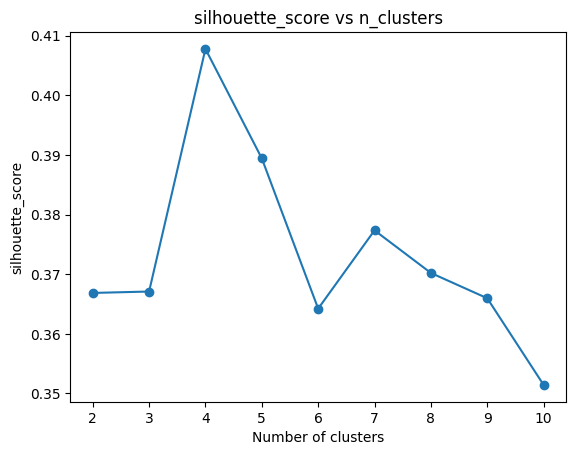

In [31]:
import matplotlib.pyplot as plt

plt.plot(range(2,11),scores,marker='o')
plt.xlabel("Number of clusters")
plt.ylabel('silhouette_score')
plt.title("silhouette_score vs n_clusters")
plt.show()

In [32]:
cluster = KMeans(n_clusters=4, max_iter=500, random_state=47).fit(X)
labels = cluster.labels_
score = silhouette_score(X, labels)
print(score)

0.4080022210067809


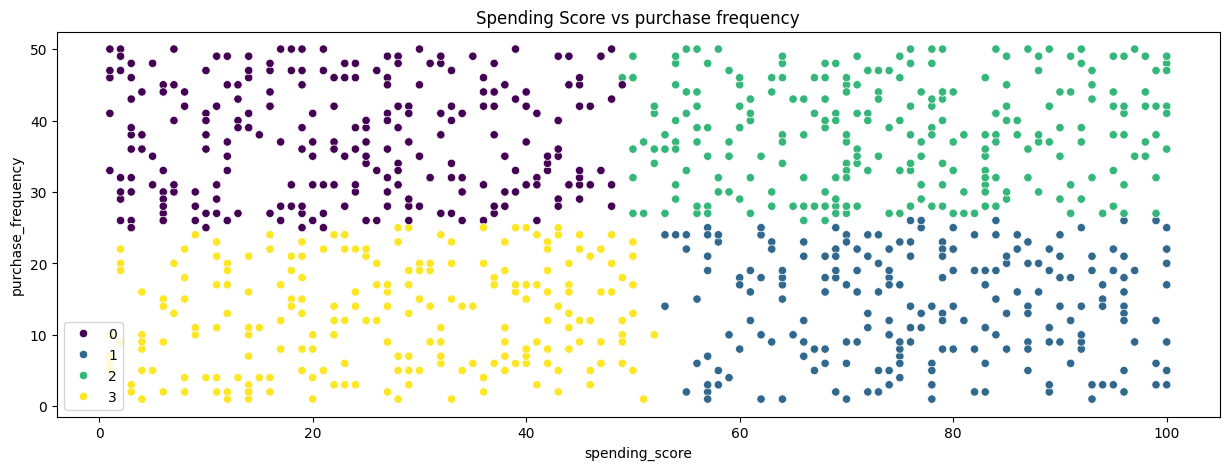

In [33]:
plt.figure(figsize=(15,5))
sns.scatterplot(data=data, x='spending_score', y='purchase_frequency',hue=labels, palette="viridis")
plt.title('Spending Score vs purchase frequency')
plt.show()

In [34]:
data['cluster'] = labels
data.head()

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount,cluster
0,1,38,Female,99342,90,3,24,Groceries,113.53,1
1,2,21,Female,78852,60,2,42,Sports,41.93,2
2,3,60,Female,126573,30,2,28,Clothing,424.36,0
3,4,40,Other,47099,74,9,5,Home & Garden,991.93,1
4,5,65,Female,140621,21,3,25,Electronics,347.08,0


Cluster Distribution

<Axes: xlabel='cluster', ylabel='count'>

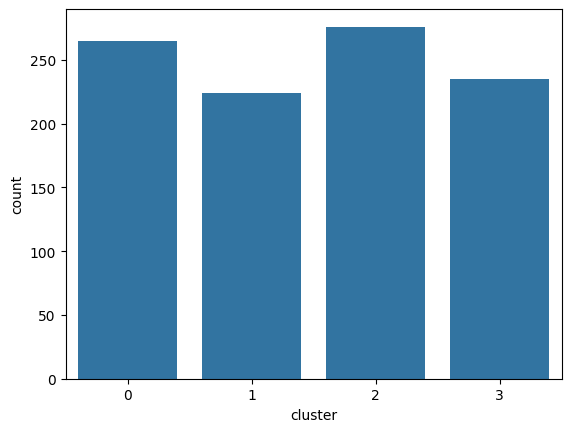

In [35]:
sns.countplot(data=data, x='cluster')

Cluster vs Spending Score

<Axes: xlabel='cluster', ylabel='spending_score'>

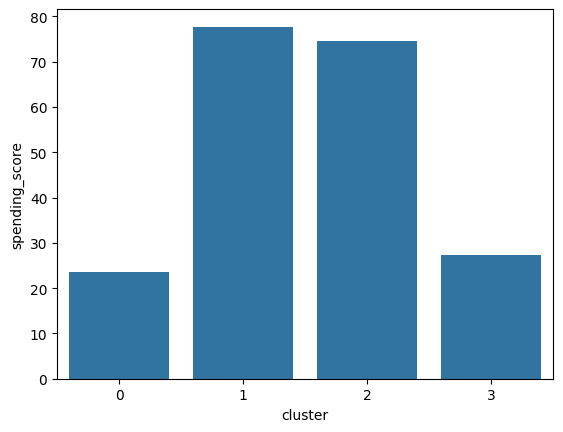

In [36]:
sns.barplot(data=data, x='cluster', y='spending_score', errorbar=None, estimator='mean')

Cluster vs Purchase Frequency

<Axes: xlabel='cluster', ylabel='purchase_frequency'>

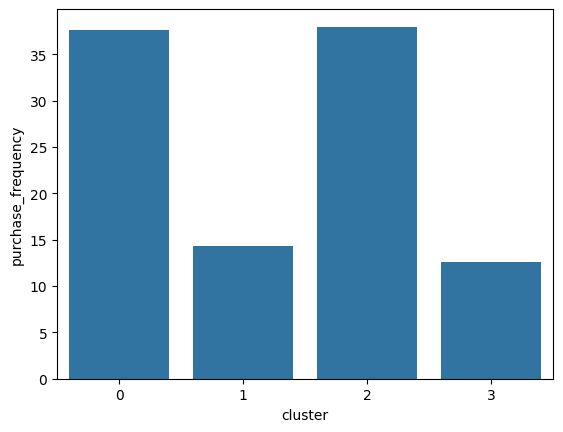

In [37]:
sns.barplot(data=data, x='cluster', y='purchase_frequency', errorbar=None, estimator='mean')